# Exploratory Data Analysis — Seismic First-Break Picking Dataset
### `Brunswick_orig_1500ms_V2.hdf5`

**Objective.** Before feeding this survey into the U-Net segmentation pipeline, this notebook builds a
ground-truth understanding of the HDF5 file: what fields actually exist, what they mean, how much of the
data is usable, where the data quality risks are, and what preprocessing the picking network genuinely needs.

**Methodological framing.** The picking task is treated as 2D image segmentation on a shot gather
(traces × time samples), following the general approach used by first-break-picking projects such as
[`first_breaks_picking`](https://github.com/DaloroAT/first_breaks_picking) — segment each gather into
*before-break* / *break* / *after-break* regions rather than picking traces independently, since neighbouring
traces in a gather share coherent wavefield structure.



## 0. Setup & Configuration

In [2]:
# If any of these are missing in your environment:
# %pip install h5py numpy pandas matplotlib tqdm

import os
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 10

# ----------------------------------------------------------------------
# CONFIGURATION — edit this
# ----------------------------------------------------------------------
FILE_PATH = "Brunswick_orig_1500ms_V2.hdf5"
GROUP_PATH = "TRACE_DATA/DEFAULT"   # auto-verified/corrected in Section 1

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

assert os.path.exists(FILE_PATH), (
    f"File not found: {FILE_PATH}\n"
    f"Update FILE_PATH above to point at your HDF5 file."
)

print(f"File: {FILE_PATH}")
print(f"Size on disk: {os.path.getsize(FILE_PATH) / 1e9:.2f} GB")


File: Brunswick_orig_1500ms_V2.hdf5
Size on disk: 15.57 GB


## 1. Structural Analysis

Goal: get a *complete, ground-truth* map of the HDF5 file — every group, every dataset, its shape and dtype —
instead of assuming a schema. This matters because vendor seismic-processing exports often carry dozens of
header fields that are irrelevant to picking, plus a handful that are critical and easy to miss
(e.g. multiple candidate break-time fields, trace-quality flags).


In [3]:
def describe_hdf5_tree(path):
    """Recursively walk the HDF5 file and list every group/dataset with shape, dtype, attrs."""
    lines = []

    def visitor(name, obj):
        depth = name.count("/")
        indent = "  " * depth
        if isinstance(obj, h5py.Group):
            lines.append(f"{indent}[GROUP] {name}/")
        elif isinstance(obj, h5py.Dataset):
            attrs = dict(obj.attrs) if len(obj.attrs) else {}
            attr_str = f"  attrs={attrs}" if attrs else ""
            lines.append(
                f"{indent}[DSET]  {name:45s} shape={str(obj.shape):18s} dtype={str(obj.dtype):10s}{attr_str}"
            )

    with h5py.File(path, "r") as f:
        print("Top-level groups:", list(f.keys()))
        f.visititems(visitor)

    print("\n".join(lines))
    return lines

tree_lines = describe_hdf5_tree(FILE_PATH)
print(f"\nTotal HDF5 objects (groups + datasets): {len(tree_lines)}")


Top-level groups: ['TRACE_DATA']
[GROUP] TRACE_DATA/
  [GROUP] TRACE_DATA/DEFAULT/
    [DSET]  TRACE_DATA/DEFAULT/ALIAS_FREQ                 shape=(4496540, 1)       dtype=uint32      attrs={'IS_TRACE_HEADER': array([1], dtype=int32), 'TRACE_HEADER_INDEX': array([51], dtype=int32), 'TRACE_HEADER_VALUE_RANGE': array([0, 0])}
    [DSET]  TRACE_DATA/DEFAULT/ALIAS_SLOPE                shape=(4496540, 1)       dtype=int32       attrs={'IS_TRACE_HEADER': array([1], dtype=int32), 'TRACE_HEADER_INDEX': array([52], dtype=int32), 'TRACE_HEADER_VALUE_RANGE': array([ 1, 29])}
    [DSET]  TRACE_DATA/DEFAULT/AZIMUTH                    shape=(4496540, 1)       dtype=int32       attrs={'IS_TRACE_HEADER': array([1], dtype=int32), 'TRACE_HEADER_INDEX': array([84], dtype=int32), 'TRACE_HEADER_VALUE_RANGE': array([   0, 3600])}
    [DSET]  TRACE_DATA/DEFAULT/CDP                        shape=(4496540, 1)       dtype=uint32      attrs={'IS_TRACE_HEADER': array([1], dtype=int32), 'TRACE_HEADER_INDEX': array(

In [4]:
def find_group_with_dataset(path, dataset_name="data_array"):
    """Locate the group holding the main trace-amplitude dataset (robust to schema drift)."""
    found = {}

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset) and name.split("/")[-1] == dataset_name:
            found["path"] = "/".join(name.split("/")[:-1])

    with h5py.File(path, "r") as f:
        f.visititems(visitor)
    return found.get("path")

detected_group = find_group_with_dataset(FILE_PATH, "data_array")
if detected_group:
    GROUP_PATH = detected_group
print(f"Using GROUP_PATH = '{GROUP_PATH}'")

with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    meta_rows = []
    for key in group.keys():
        dset = group[key]
        if isinstance(dset, h5py.Dataset):
            meta_rows.append({
                "field": key,
                "shape": dset.shape,
                "dtype": str(dset.dtype),
                "size_MB": round(dset.size * dset.dtype.itemsize / 1e6, 3),
            })
    meta_df = pd.DataFrame(meta_rows).sort_values("size_MB", ascending=False).reset_index(drop=True)

pd.set_option("display.max_rows", 200)
meta_df


Using GROUP_PATH = 'TRACE_DATA/DEFAULT'


,field,shape,dtype,size_MB
0,data_array,"(4496540, 751)",float32,13507.606
1,OFFSET_FLT,"(4496540, 1)",float64,35.972
2,ALIAS_FREQ,"(4496540, 1)",uint32,17.986
3,REPEAT,"(4496540, 1)",uint32,17.986
4,SOURCE_HT,"(4496540, 1)",int32,17.986
5,SOURCE_DEP,"(4496540, 1)",int32,17.986
6,SOURCE_DAT,"(4496540, 1)",int32,17.986
7,SOURCENUM,"(4496540, 1)",uint32,17.986
8,SHOT_PEG_DIST,"(4496540, 1)",float32,17.986
9,SHOT_PEG,"(4496540, 1)",uint32,17.986


### Field semantics (curated)

The naming convention here (`SHOT_PEG`, `REC_PEG`, `INTERNAL_SORT1/2`, `REF_MODEL_*_STATIC`) is consistent
with a land-seismic **processing-software trace-header export** (e.g. VISTA/ProMAX-style), not a raw SEG-Y
dump — meaning several fields below were likely computed by a *prior* processing pass, not just acquired.

| Group | Fields | Meaning |
|---|---|---|
| **Trace data** | `data_array` | The actual seismic amplitudes — shape `(n_traces, n_samples)`. This is `X`. |
| **Gather identifiers** | `SHOTID`, `CHANNEL`, `CDP`, `CDPTRACE`, `RECORDNUM`, `LINE`, `REEL` | `SHOTID` groups traces into common-source gathers (this is the natural unit for the 2D U-Net input). `CHANNEL` is the receiver index within a shot. |
| **Source geometry** | `SOURCE_X/Y`, `SOURCE_DAT`, `SOURCE_DEP`, `SOURCE_HT`, `SOURCE_WATER`, `SOURCE_UPHOLE_TIME`, `SHOT_PEG(_DIST)` | Source position and near-surface source conditions. |
| **Receiver geometry** | `REC_X/Y`, `REC_DAT`, `REC_HT`, `REC_WATER`, `REC_UPHOLE_TIME`, `REC_PEG(_DIST)` | Receiver position and near-surface receiver conditions. |
| **Offset / bin geometry** | `OFFSET`, `OFFSET_FLT`, `AZIMUTH`, `INLINE`, `CROSSLINE`, `CDP_X/Y`, `COORD_SCALE`, `COORD_UNIT` | `OFFSET`/`OFFSET_FLT` = source-receiver distance — the single most important variable for moveout / QC plots below. |
| **Sampling / timing** | `SAMP_RATE`, `DELAY`, `SAMP_NUM`, `DATA_START`, `DATA_STOP`, `LAG_TIME_A/B`, `TIME_BASE` | Defines how a sample index maps to real time. |
| **Break-time labels (⚠ 3 candidates)** | `SPARE1`, `FIRST_BREAK_TIME`, `MODELLED_BREAK_TIME` | `SPARE1` is a *generic spare field* being repurposed (in the original notebook) to hold picks — but `FIRST_BREAK_TIME` is an explicit, named field, and `MODELLED_BREAK_TIME` looks like an independent theoretical/refraction-statics estimate. **These need to be reconciled before training — see Section 2.2.** |
| **QC / trace flags** | `TRTYPE`, `USE`, `CORR`, `LASTTR`, `GAP_SIZE`, `HORI_SUM`/`VERT_SUM`, `REPEAT` | `TRTYPE` is the SEG-Y-style trace-type flag (live/dead/dummy/...) — the primary tool for excluding unusable traces. |
| **Acquisition instrument** | `GAIN_TYPE`, `INSTR_GAIN_CONSTANT/INIT_GAIN`, `LOW/HIGH_CUT_FREQ/SLOPE`, `NOTCH_FREQ/SLOPE`, `ALIAS_FREQ/SLOPE`, `SWEEP_*`, `OVERTRAVEL` | Recording instrument settings and (for vibroseis) sweep parameters — useful for choosing a bandpass filter. |
| **Static corrections** | `SOURCE_STATIC`, `REC_STATIC`, `TOTAL_STATIC`, `REF_MODEL_*_STATIC`, `REF_RESID_*_STATIC`, `REF_TOTAL_STATIC` | Presence of *reference-model* and *residual* statics strongly suggests a refraction-statics analysis has already been run on this survey — this is almost certainly where `MODELLED_BREAK_TIME` comes from, i.e. an independent, physically-modeled cross-check on the manual/automatic picks. |
| **Acquisition timestamp** | `YEAR`, `DAY`, `HOUR`, `MINUTE`, `SECOND` | Acquisition date/time per trace. |
| **File-level metadata** | `reel_headers`, `reel_text_header`, `processing_history`, `support_file_list` | Survey-level metadata, not per-trace. |


In [5]:
with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    samp_rate_raw = group["SAMP_RATE"][:500].flatten() if "SAMP_RATE" in group else None
    n_samples = group["data_array"].shape[1]

print("Raw SAMP_RATE header sample (first 10):", samp_rate_raw[:10] if samp_rate_raw is not None else "N/A")

dt_ms = None
if samp_rate_raw is not None:
    unique_rates = np.unique(samp_rate_raw)
    print("Unique SAMP_RATE values across first 500 traces:", unique_rates)
    if len(unique_rates) == 1:
        # SEG-Y convention: sample interval is stored in microseconds.
        dt_us = float(unique_rates[0])
        dt_ms = dt_us / 1000.0
        record_length_ms = dt_ms * (n_samples - 1)
        print(f"\nSample interval: {dt_us:.1f} µs  ({dt_ms:.3f} ms)")
        print(f"Samples per trace: {n_samples}")
        print(f"Record length: {record_length_ms:.1f} ms  ({record_length_ms / 1000:.3f} s)")
        matches_assumed = abs(dt_ms - 2.0) < 1e-6
        print(f"\nSanity check vs. the '×2' ms-conversion assumed in the original notebook: "
              f"{'MATCHES (dt=2ms)' if matches_assumed else 'DOES NOT MATCH — fix downstream ms conversions!'}")
    else:
        print("\n⚠ SAMP_RATE is NOT constant across traces — do not assume a single fixed dt for the whole survey.")
        dt_ms = float(np.median(unique_rates)) / 1000.0
        print(f"Falling back to median dt = {dt_ms:.3f} ms for illustrative plots only.")

if dt_ms is None:
    dt_ms = 2.0
    print("SAMP_RATE not found — defaulting to dt=2ms as a placeholder. VERIFY THIS.")


Raw SAMP_RATE header sample (first 10): [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]
Unique SAMP_RATE values across first 500 traces: [2000]

Sample interval: 2000.0 µs  (2.000 ms)
Samples per trace: 751
Record length: 1500.0 ms  (1.500 s)

Sanity check vs. the '×2' ms-conversion assumed in the original notebook: MATCHES (dt=2ms)


## 2. Quantitative Metrics

### 2.1 Traces, shots, and gather-size distribution

Total traces:                         4,496,540
Total unique shots:                   1,541
Data pre-sorted contiguously by SHOTID: True

Samples per trace:                    751

Traces per shot — min: 2135, max: 3355, mean: 2917.9, median: 2975, std: 363.7


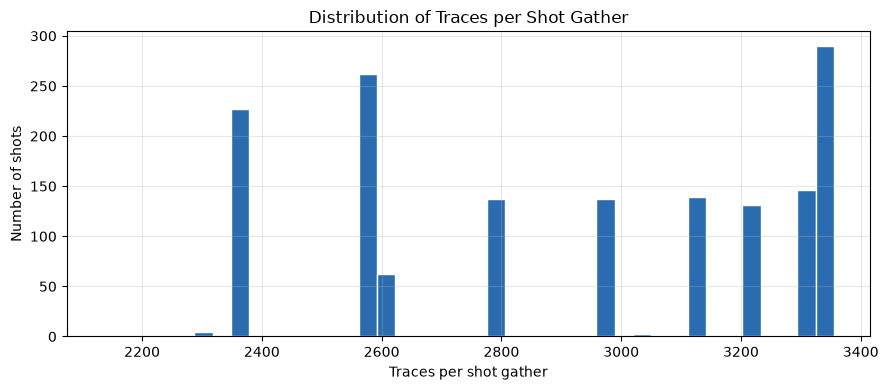

In [6]:
with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    shotids = group["SHOTID"][:].flatten()

n_traces_total = len(shotids)
unique_shots, shot_start_idx, traces_per_shot = np.unique(shotids, return_index=True, return_counts=True)
n_shots = len(unique_shots)

# The filename ends in "_sorted" — verify traces really are grouped contiguously by shot.
# If true, gather extraction can use a fast contiguous HDF5 slice instead of slow boolean
# fancy-indexing across the whole dataset (relevant for Section 4's visualizations).
is_sorted_by_shot = bool(np.all(np.diff(shotids) >= 0))
shot_boundaries = (
    {int(sid): (int(s), int(s + c)) for sid, s, c in zip(unique_shots, shot_start_idx, traces_per_shot)}
    if is_sorted_by_shot else None
)

print(f"Total traces:                         {n_traces_total:,}")
print(f"Total unique shots:                   {n_shots:,}")
print(f"Data pre-sorted contiguously by SHOTID: {is_sorted_by_shot}")
print(f"\nSamples per trace:                    {n_samples}")
print(f"\nTraces per shot — min: {traces_per_shot.min()}, max: {traces_per_shot.max()}, "
      f"mean: {traces_per_shot.mean():.1f}, median: {int(np.median(traces_per_shot))}, "
      f"std: {traces_per_shot.std():.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(traces_per_shot, bins=40, color="#2b6cb0", edgecolor="white")
ax.set_xlabel("Traces per shot gather")
ax.set_ylabel("Number of shots")
ax.set_title("Distribution of Traces per Shot Gather")
plt.tight_layout()
plt.show()


### 2.2 Labeled vs. unlabeled data — and reconciling the three candidate break-time fields

In [7]:
PICK_FIELD_CANDIDATES = ["SPARE1", "FIRST_BREAK_TIME", "MODELLED_BREAK_TIME"]

with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    picks = {fld: group[fld][:].flatten().astype(np.float64)
             for fld in PICK_FIELD_CANDIDATES if fld in group}

print("=" * 70)
print("LABEL COVERAGE — per candidate pick field")
print("=" * 70)
label_summary = []
for field, arr in picks.items():
    valid = (arr > 0) & (arr < n_samples) & np.isfinite(arr)
    n_valid = int(valid.sum())
    label_summary.append({
        "field": field,
        "n_labeled": n_valid,
        "n_unlabeled": len(arr) - n_valid,
        "pct_labeled": round(100 * n_valid / len(arr), 2),
        "min": float(np.nanmin(arr)), "max": float(np.nanmax(arr)),
        "mean_valid": float(arr[valid].mean()) if n_valid else np.nan,
    })
label_df = pd.DataFrame(label_summary)
label_df


LABEL COVERAGE — per candidate pick field


,field,n_labeled,n_unlabeled,pct_labeled,min,max,mean_valid
0,SPARE1,3334988,1161552,74.17,-1.0,1358.0,374.375765
1,FIRST_BREAK_TIME,0,4496540,0.00,0.0,0.0,NaN
2,MODELLED_BREAK_TIME,0,4496540,0.00,0.0,0.0,NaN


In [8]:
# Cross-check: does SPARE1 (assumed to be a pick in *samples*) agree with
# FIRST_BREAK_TIME (assumed to be in *ms*) once converted with the dt derived in Section 1?
if "SPARE1" in picks and "FIRST_BREAK_TIME" in picks:
    spare1 = picks["SPARE1"]
    fbt = picks["FIRST_BREAK_TIME"]

    both_valid = (spare1 > 0) & (spare1 < n_samples) & (fbt > 0) & np.isfinite(fbt)
    print(f"Traces with both SPARE1 and FIRST_BREAK_TIME populated: {both_valid.sum():,} "
          f"({100 * both_valid.sum() / len(spare1):.1f}%)")

    if both_valid.sum() > 0:
        spare1_ms_guess = spare1[both_valid] * dt_ms
        fbt_valid = fbt[both_valid]

        corr = np.corrcoef(spare1_ms_guess, fbt_valid)[0, 1]
        diff = spare1_ms_guess - fbt_valid

        print(f"Correlation (SPARE1×dt_ms  vs  FIRST_BREAK_TIME): {corr:.4f}")
        print(f"Residual — mean: {diff.mean():.2f} ms | median: {np.median(diff):.2f} ms | std: {diff.std():.2f} ms")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        idx = rng.choice(len(fbt_valid), size=min(50000, len(fbt_valid)), replace=False)
        axes[0].scatter(fbt_valid[idx], spare1_ms_guess[idx], s=2, alpha=0.3, color="#2b6cb0")
        lims = [0, max(fbt_valid.max(), spare1_ms_guess.max())]
        axes[0].plot(lims, lims, "r--", lw=1, label="y = x")
        axes[0].set_xlabel("FIRST_BREAK_TIME (ms)")
        axes[0].set_ylabel("SPARE1 × dt (ms)")
        axes[0].set_title(f"Field Agreement (corr={corr:.3f})")
        axes[0].legend()

        axes[1].hist(diff, bins=80, color="#c53030")
        axes[1].set_xlabel("SPARE1×dt − FIRST_BREAK_TIME (ms)")
        axes[1].set_title("Residual Distribution")
        plt.tight_layout()
        plt.show()

        if corr > 0.98 and abs(diff.mean()) < 2 * dt_ms:
            print("\n✅ SPARE1 and FIRST_BREAK_TIME are consistent — either can be used as the label field.")
        else:
            print("\n⚠️  SPARE1 and FIRST_BREAK_TIME disagree meaningfully. Determine which one is the intended "
                  "ground truth BEFORE building training masks — this directly determines what the network learns.")
    else:
        print("No overlapping valid picks between the two fields to compare — inspect manually.")
else:
    print("Need both SPARE1 and FIRST_BREAK_TIME present in this file to run this cross-check.")

# Decide which field downstream cells will treat as the primary label.
# CHANGE THIS if the reconciliation above points to a different field.
main_pick_field = "SPARE1" if "SPARE1" in picks else next(iter(picks))
main_picks = picks[main_pick_field]
valid_mask = (main_picks > 0) & (main_picks < n_samples) & np.isfinite(main_picks)
print(f"\n--> Using '{main_pick_field}' as the primary label field for the rest of this notebook.")


Traces with both SPARE1 and FIRST_BREAK_TIME populated: 0 (0.0%)
No overlapping valid picks between the two fields to compare — inspect manually.

--> Using 'SPARE1' as the primary label field for the rest of this notebook.


### 2.3 Trace-quality / usability flags (`TRTYPE`, `USE`)

In [9]:
with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    trtype = group["TRTYPE"][:].flatten() if "TRTYPE" in group else None
    use_flag = group["USE"][:].flatten() if "USE" in group else None

# Standard SEG-Y-family trace-type (TRID) codes — vendor software may extend this.
SEGY_TRTYPE_MAP = {
    1: "Seismic (live)", 2: "Dead", 3: "Dummy", 4: "Time break",
    5: "Uphole", 6: "Sweep", 7: "Timing", 8: "Water break",
}

if trtype is not None:
    vals, counts = np.unique(trtype, return_counts=True)
    print("TRTYPE distribution (trace-type flag):")
    for v, c in zip(vals, counts):
        label = SEGY_TRTYPE_MAP.get(int(v), "Unknown / vendor-specific")
        print(f"  {v:>4} ({label:20s}): {c:>10,} traces  ({100 * c / len(trtype):5.2f}%)")
else:
    print("No TRTYPE field found in this file.")

if use_flag is not None:
    vals, counts = np.unique(use_flag, return_counts=True)
    print("\nUSE flag distribution:")
    for v, c in zip(vals, counts):
        print(f"  {v:>4}: {c:>10,} traces  ({100 * c / len(use_flag):5.2f}%)")
else:
    print("No USE field found in this file.")


TRTYPE distribution (trace-type flag):
     1 (Seismic (live)      ):  4,496,540 traces  (100.00%)

USE flag distribution:
     0:  4,496,540 traces  (100.00%)


## 3. Data Quality & Distributions

### 3.1 Global amplitude statistics (streamed — exact min/max/mean + sampled percentiles)

GLOBAL AMPLITUDE STATISTICS (exact, streamed over the full dataset)
Min:  -710.404541
Max:  716.025635
Mean: -0.000024
Std:  1.185122
NaN values: 0
Inf values: 0

Percentiles (from a 24,000-value random sample):
    0.1th: -2.098275
      1th: -0.333564
      5th: -0.075044
     25th: -0.008767
     50th:  0.000009
     75th:  0.009046
     95th:  0.077827
     99th:  0.344145
   99.9th:  2.596890


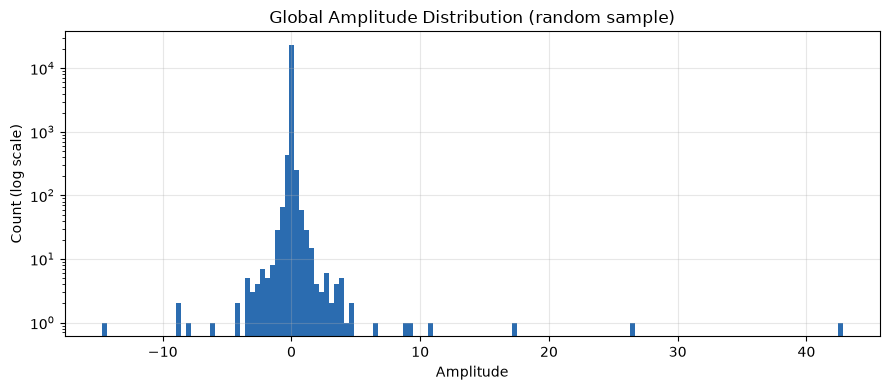


✅ No NaN/Inf values found in data_array.


In [10]:
def compute_global_amplitude_stats(path, group_path, dataset="data_array",
                                     chunk_size=20000, sample_fraction=0.05, seed=RANDOM_SEED):
    """
    Streams the trace-amplitude dataset chunk-by-chunk to get EXACT global
    min/max/mean/std and NaN/Inf counts without loading the full ~3+ GB array,
    while simultaneously building a random sub-sample for fast percentile/
    histogram estimation.
    """
    rng_local = np.random.default_rng(seed)
    with h5py.File(path, "r") as f:
        dset = f[group_path][dataset]
        n_traces, n_samp = dset.shape

        running_min, running_max = np.inf, -np.inf
        running_sum, running_sumsq, running_n = 0.0, 0.0, 0
        nan_count, inf_count = 0, 0
        sample_values = []

        n_chunks = (n_traces + chunk_size - 1) // chunk_size
        for start in tqdm(range(0, n_traces, chunk_size), total=n_chunks, desc="Scanning amplitudes"):
            end = min(start + chunk_size, n_traces)
            chunk = dset[start:end, :]

            nan_count += int(np.isnan(chunk).sum())
            inf_count += int(np.isinf(chunk).sum())

            finite_vals = chunk[np.isfinite(chunk)]
            if finite_vals.size:
                running_min = min(running_min, float(finite_vals.min()))
                running_max = max(running_max, float(finite_vals.max()))
                running_sum += finite_vals.sum(dtype=np.float64)
                running_sumsq += np.square(finite_vals, dtype=np.float64).sum()
                running_n += finite_vals.size

            if rng_local.random() < sample_fraction:
                flat = chunk.flatten()
                take = rng_local.choice(flat.size, size=min(2000, flat.size), replace=False)
                sample_values.append(flat[take])

        mean = running_sum / running_n
        std = float(np.sqrt(max(running_sumsq / running_n - mean ** 2, 0.0)))
        sample_values = np.concatenate(sample_values) if sample_values else np.array([])

        return {
            "n_traces": n_traces, "n_samples_per_trace": n_samp,
            "min": running_min, "max": running_max,
            "mean": mean, "std": std,
            "nan_count": nan_count, "inf_count": inf_count,
            "sample_values": sample_values,
        }

amp_stats = compute_global_amplitude_stats(FILE_PATH, GROUP_PATH, chunk_size=20000, sample_fraction=0.05)

print("=" * 60)
print("GLOBAL AMPLITUDE STATISTICS (exact, streamed over the full dataset)")
print("=" * 60)
print(f"Min:  {amp_stats['min']:.6f}")
print(f"Max:  {amp_stats['max']:.6f}")
print(f"Mean: {amp_stats['mean']:.6f}")
print(f"Std:  {amp_stats['std']:.6f}")
print(f"NaN values: {amp_stats['nan_count']:,}")
print(f"Inf values: {amp_stats['inf_count']:,}")

if amp_stats["sample_values"].size:
    pctiles = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
    pct = np.percentile(amp_stats["sample_values"], pctiles)
    print(f"\nPercentiles (from a {amp_stats['sample_values'].size:,}-value random sample):")
    for p, v in zip(pctiles, pct):
        print(f"  {p:>5}th: {v: .6f}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(amp_stats["sample_values"], bins=150, color="#2b6cb0")
    ax.set_yscale("log")
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Count (log scale)")
    ax.set_title("Global Amplitude Distribution (random sample)")
    plt.tight_layout()
    plt.show()

if amp_stats["nan_count"] == 0 and amp_stats["inf_count"] == 0:
    print("\n✅ No NaN/Inf values found in data_array.")
else:
    print("\n⚠️  NaN/Inf values present — these WILL break U-Net training (loss becomes NaN). "
          "Locate and drop/impute the affected traces before training.")


### 3.2 Per-trace RMS energy — dead / low-energy trace detection

Traces with near-zero RMS (< 1e-08): 2 (0.000%)
Traces in bottom 1 percentile of RMS energy: 44,966


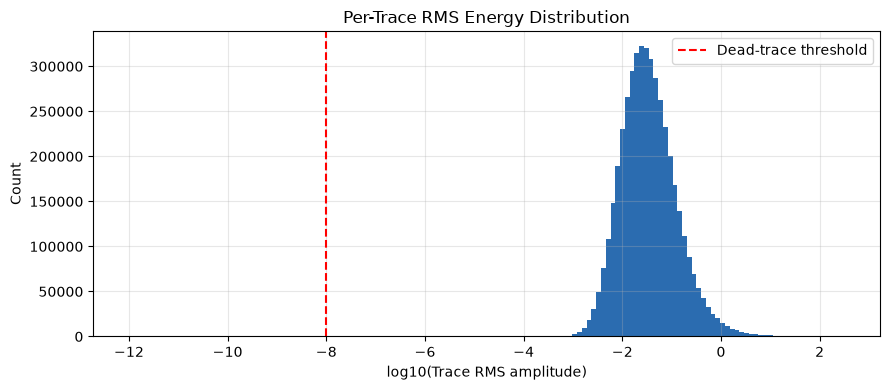

In [11]:
def compute_per_trace_rms(path, group_path, dataset="data_array", chunk_size=20000):
    """Full-dataset, chunked per-trace RMS + peak-abs-amplitude (needed for later normalization)."""
    with h5py.File(path, "r") as f:
        dset = f[group_path][dataset]
        n_traces = dset.shape[0]
        rms = np.empty(n_traces, dtype=np.float32)
        max_abs = np.empty(n_traces, dtype=np.float32)

        n_chunks = (n_traces + chunk_size - 1) // chunk_size
        for start in tqdm(range(0, n_traces, chunk_size), total=n_chunks, desc="Computing per-trace RMS"):
            end = min(start + chunk_size, n_traces)
            chunk = dset[start:end, :]
            rms[start:end] = np.sqrt(np.mean(np.square(chunk, dtype=np.float64), axis=1))
            max_abs[start:end] = np.max(np.abs(chunk), axis=1)
    return rms, max_abs

trace_rms, trace_max_abs = compute_per_trace_rms(FILE_PATH, GROUP_PATH)

DEAD_TRACE_RMS_THRESHOLD = 1e-8  # essentially all-zero traces
dead_by_rms = trace_rms < DEAD_TRACE_RMS_THRESHOLD
low_energy_by_pctile = trace_rms < np.percentile(trace_rms, 1)

print(f"Traces with near-zero RMS (< {DEAD_TRACE_RMS_THRESHOLD}): {dead_by_rms.sum():,} "
      f"({100 * dead_by_rms.sum() / len(trace_rms):.3f}%)")
print(f"Traces in bottom 1 percentile of RMS energy: {low_energy_by_pctile.sum():,}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(trace_rms + 1e-12), bins=150, color="#2b6cb0")
ax.axvline(np.log10(DEAD_TRACE_RMS_THRESHOLD), color="red", ls="--", label="Dead-trace threshold")
ax.set_xlabel("log10(Trace RMS amplitude)")
ax.set_ylabel("Count")
ax.set_title("Per-Trace RMS Energy Distribution")
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# Cross-check the RMS-based dead-trace detector against the header's own TRTYPE flag.
if trtype is not None:
    df_qc = pd.DataFrame({"trtype": trtype, "dead_by_rms": dead_by_rms})
    crosstab = pd.crosstab(df_qc["trtype"], df_qc["dead_by_rms"])
    crosstab.columns = [f"RMS says {'DEAD' if c else 'live'}" for c in crosstab.columns]
    print("Cross-check: header TRTYPE flag vs. RMS-based dead-trace detection")
    print(crosstab)
    print("\nIf many traces are RMS-dead but TRTYPE marks them 'live' (or vice-versa), the header flag alone "
          "is not reliable for filtering training data — use the RMS-based check as an additional/authoritative filter.")
else:
    print("No TRTYPE field to cross-check against — rely on the RMS-based detector alone.")


Cross-check: header TRTYPE flag vs. RMS-based dead-trace detection
        RMS says live  RMS says DEAD
trtype                              
1             4496538              2

If many traces are RMS-dead but TRTYPE marks them 'live' (or vice-versa), the header flag alone is not reliable for filtering training data — use the RMS-based check as an additional/authoritative filter.


### 3.3 Amplitude vs. offset (geometric spreading / attenuation)

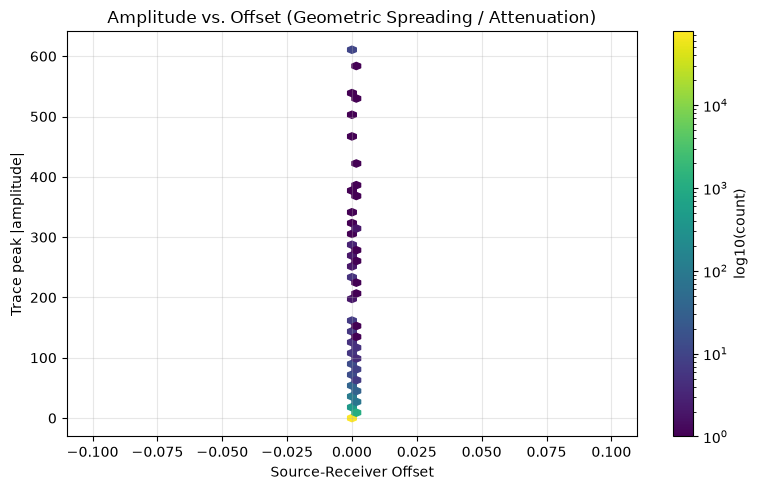

A clear downward trend confirms amplitude decays with offset, as expected physically — this is the direct evidence for why PER-TRACE normalization (Section 5) is required before training, not a single global scale factor.


In [13]:
with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    offset = (group["OFFSET_FLT"][:].flatten() if "OFFSET_FLT" in group
              else group["OFFSET"][:].flatten()).astype(np.float64)

fig, ax = plt.subplots(figsize=(8, 5))
idx = rng.choice(len(offset), size=min(80000, len(offset)), replace=False)
hb = ax.hexbin(np.abs(offset[idx]), trace_max_abs[idx], gridsize=60, bins="log", cmap="viridis")
ax.set_xlabel("Source-Receiver Offset")
ax.set_ylabel("Trace peak |amplitude|")
ax.set_title("Amplitude vs. Offset (Geometric Spreading / Attenuation)")
plt.colorbar(hb, label="log10(count)")
plt.tight_layout()
plt.show()
print("A clear downward trend confirms amplitude decays with offset, as expected physically — "
      "this is the direct evidence for why PER-TRACE normalization (Section 5) is required before training, "
      "not a single global scale factor.")


### 3.4 First-break pick validity & distribution

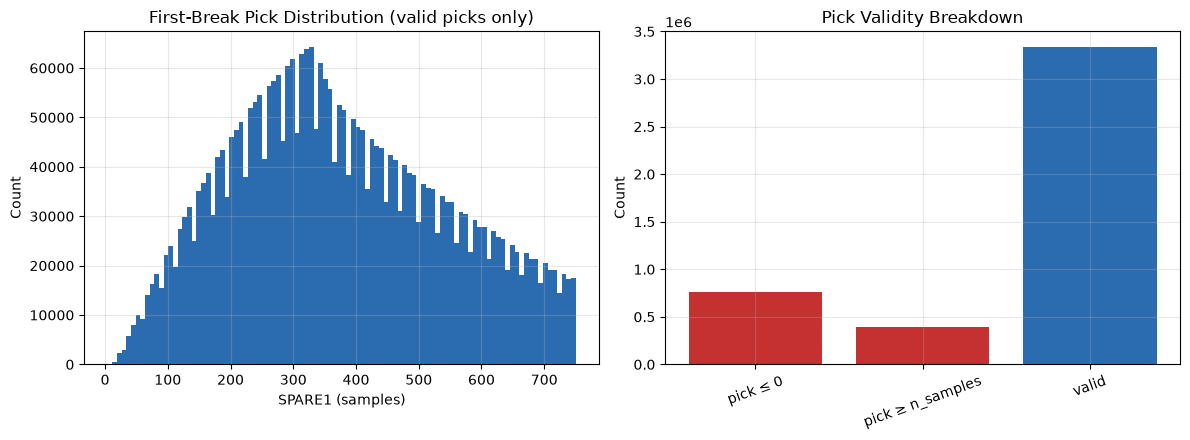

Valid picks: 3,334,988 / 4,496,540 (74.17%) using field 'SPARE1'


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(main_picks[valid_mask], bins=100, color="#2b6cb0")
axes[0].set_xlabel(f"{main_pick_field} (samples)")
axes[0].set_ylabel("Count")
axes[0].set_title("First-Break Pick Distribution (valid picks only)")

invalid_reason = np.full(len(main_picks), "valid", dtype=object)
invalid_reason[main_picks <= 0] = "pick ≤ 0"
invalid_reason[main_picks >= n_samples] = "pick ≥ n_samples"
invalid_reason[~np.isfinite(main_picks)] = "NaN/Inf"
invalid_reason[valid_mask] = "valid"
vals, counts = np.unique(invalid_reason, return_counts=True)
colors = ["#2b6cb0" if v == "valid" else "#c53030" for v in vals]
axes[1].bar(vals, counts, color=colors)
axes[1].set_ylabel("Count")
axes[1].set_title("Pick Validity Breakdown")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(f"Valid picks: {valid_mask.sum():,} / {len(main_picks):,} "
      f"({100 * valid_mask.sum() / len(main_picks):.2f}%) using field '{main_pick_field}'")


### 3.5 Geometry consistency check — does `OFFSET` agree with the coordinates?

Median |computed_offset − header_offset|: 2123.18
95th-pct |residual|: 4887.53


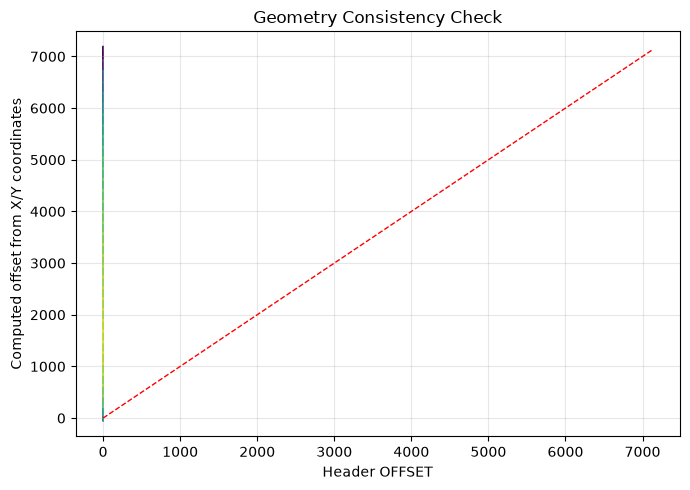


⚠️  Notable disagreement between header OFFSET and coordinate-derived offset. Check the COORD_SCALE / COORD_UNIT interpretation before trusting offset-dependent QC (e.g. travel-time curves below).


In [15]:
with h5py.File(FILE_PATH, "r") as f:
    group = f[GROUP_PATH]
    rec_x = group["REC_X"][:].flatten().astype(np.float64)
    rec_y = group["REC_Y"][:].flatten().astype(np.float64)
    src_x = group["SOURCE_X"][:].flatten().astype(np.float64)
    src_y = group["SOURCE_Y"][:].flatten().astype(np.float64)
    coord_scale_raw = (group["COORD_SCALE"][:].flatten().astype(np.float64)
                        if "COORD_SCALE" in group else np.ones(len(rec_x)))

def apply_segy_coord_scale(coord, scale):
    """SEG-Y convention: positive scale multiplies, negative scale divides, 0/1 = no scaling."""
    scale = np.where(scale == 0, 1, scale)
    return np.where(scale > 0, coord * scale, coord / np.abs(scale))

rec_x_s = apply_segy_coord_scale(rec_x, coord_scale_raw)
rec_y_s = apply_segy_coord_scale(rec_y, coord_scale_raw)
src_x_s = apply_segy_coord_scale(src_x, coord_scale_raw)
src_y_s = apply_segy_coord_scale(src_y, coord_scale_raw)

computed_offset = np.sqrt((rec_x_s - src_x_s) ** 2 + (rec_y_s - src_y_s) ** 2)
header_offset = np.abs(offset)
residual = computed_offset - header_offset

print(f"Median |computed_offset − header_offset|: {np.median(np.abs(residual)):.2f}")
print(f"95th-pct |residual|: {np.percentile(np.abs(residual), 95):.2f}")

idx2 = rng.choice(len(residual), size=min(80000, len(residual)), replace=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hexbin(header_offset[idx2], computed_offset[idx2], gridsize=60, bins="log", cmap="viridis")
lims = [0, max(header_offset[idx2].max(), computed_offset[idx2].max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Header OFFSET")
ax.set_ylabel("Computed offset from X/Y coordinates")
ax.set_title("Geometry Consistency Check")
plt.tight_layout()
plt.show()

if np.median(np.abs(residual)) < 1.0:
    print("\n✅ Header offsets are consistent with receiver/source coordinates — geometry is trustworthy.")
else:
    print("\n⚠️  Notable disagreement between header OFFSET and coordinate-derived offset. Check the "
          "COORD_SCALE / COORD_UNIT interpretation before trusting offset-dependent QC (e.g. travel-time curves below).")


## 4. Domain-Specific Visualization

Following the segmentation framing used by `first_breaks_picking`, each shot gather is visualized three ways:
1. **Variable-density image** with the first-break pick overlaid as a line (the actual U-Net input/label pair).
2. **Wiggle trace view**, the traditional seismologist's QC view, with picks marked per trace.
3. **Travel-time curve (hodochrone)** — offset vs. pick time — the classic refraction-seismology QC plot.
   Points that fall far off the moveout trend are visually obvious bad picks.

Because the file appears to be pre-sorted by `SHOTID` (verified in §2.1), gather extraction below uses a fast
**contiguous HDF5 slice** rather than boolean fancy-indexing across the whole dataset — the latter is what the
original notebook's `data_array[mask, :]` pattern does, and it is dramatically slower on a multi-GB dataset.


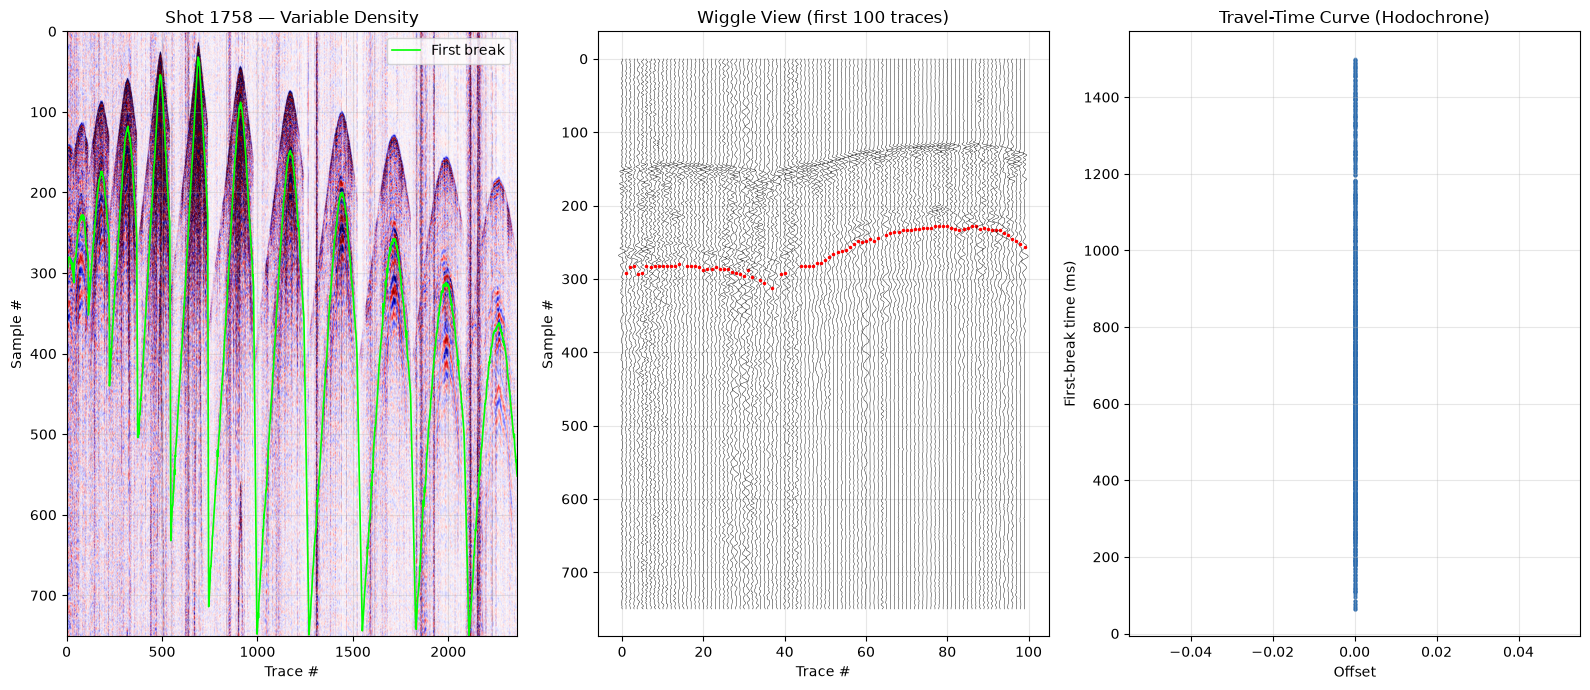

Shot 1758: 2362 traces, 1997 valid picks (84.5%), pick range 32-750 samples


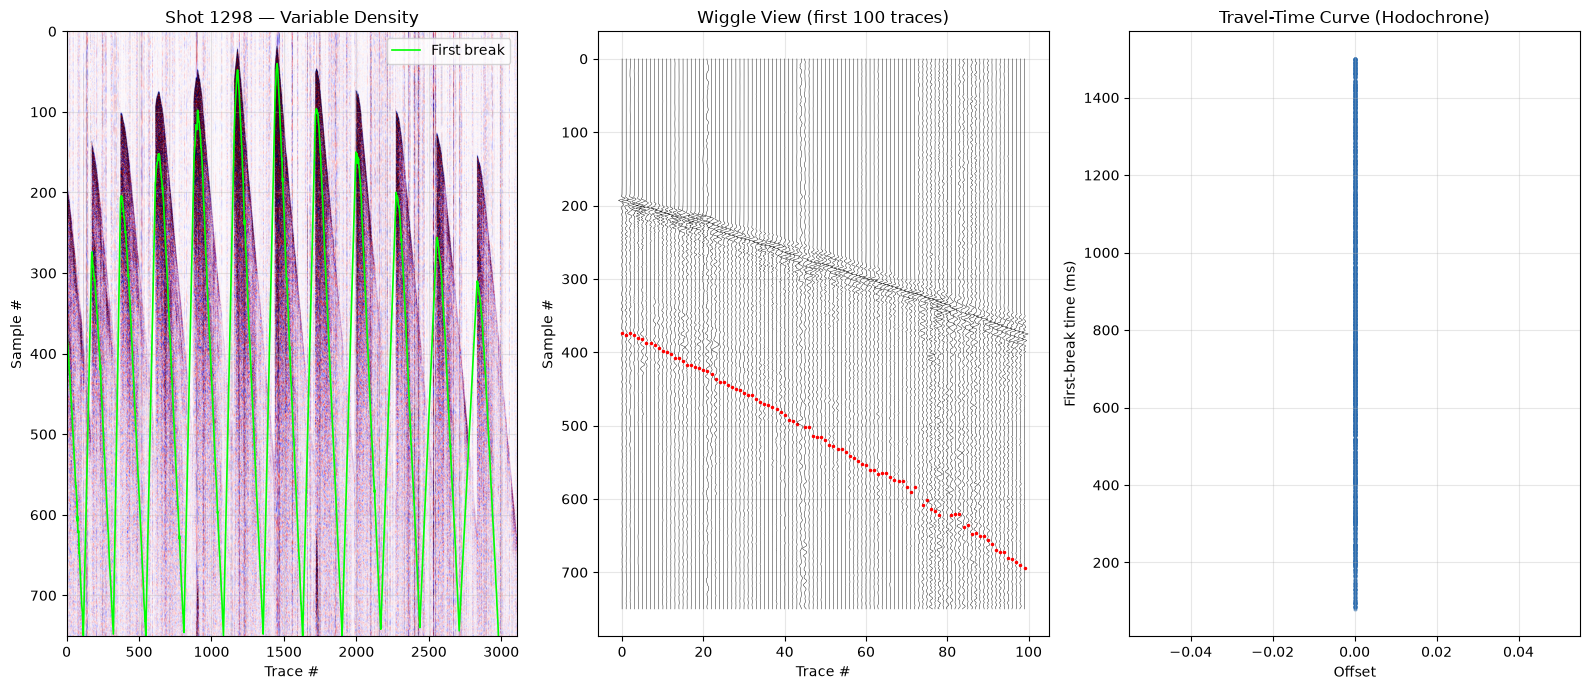

Shot 1298: 3111 traces, 1828 valid picks (58.8%), pick range 40-750 samples


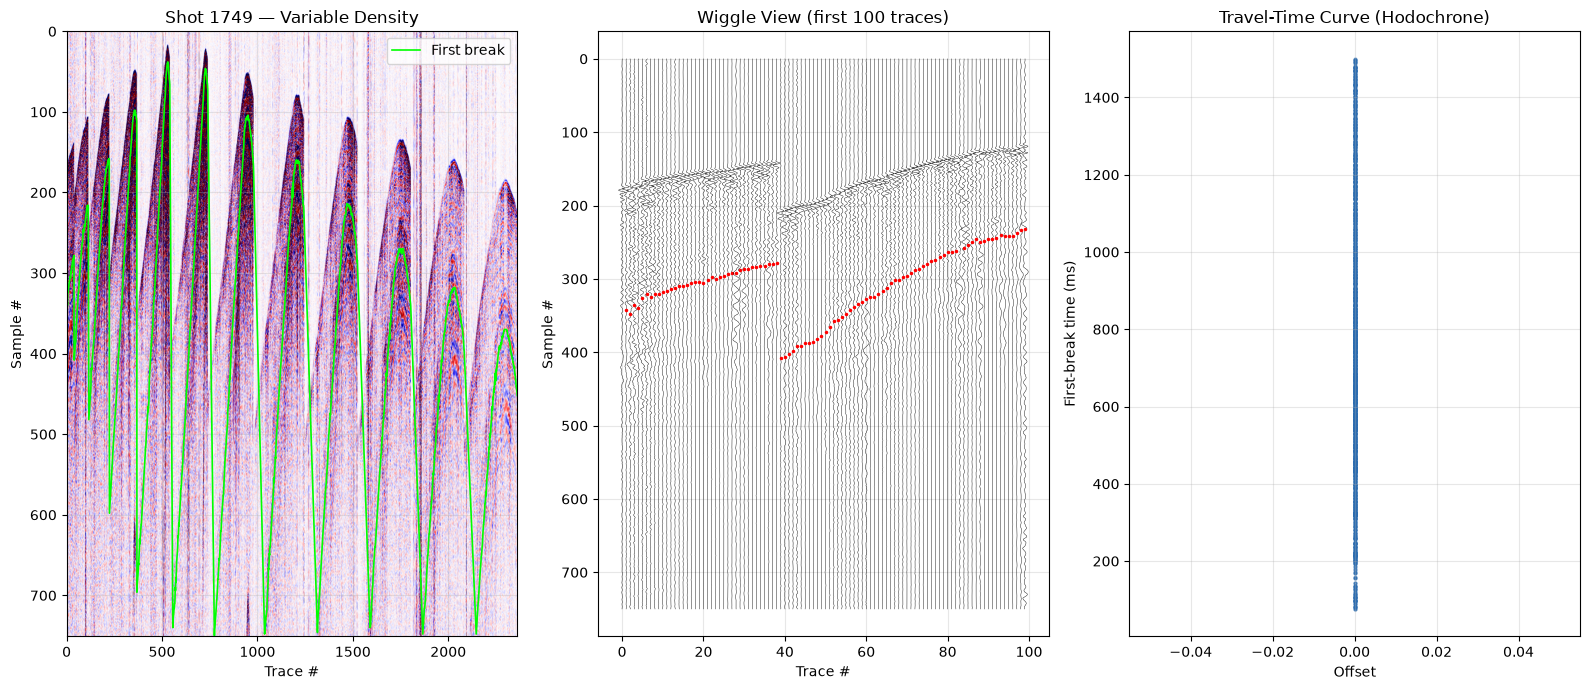

Shot 1749: 2362 traces, 1890 valid picks (80.0%), pick range 38-750 samples


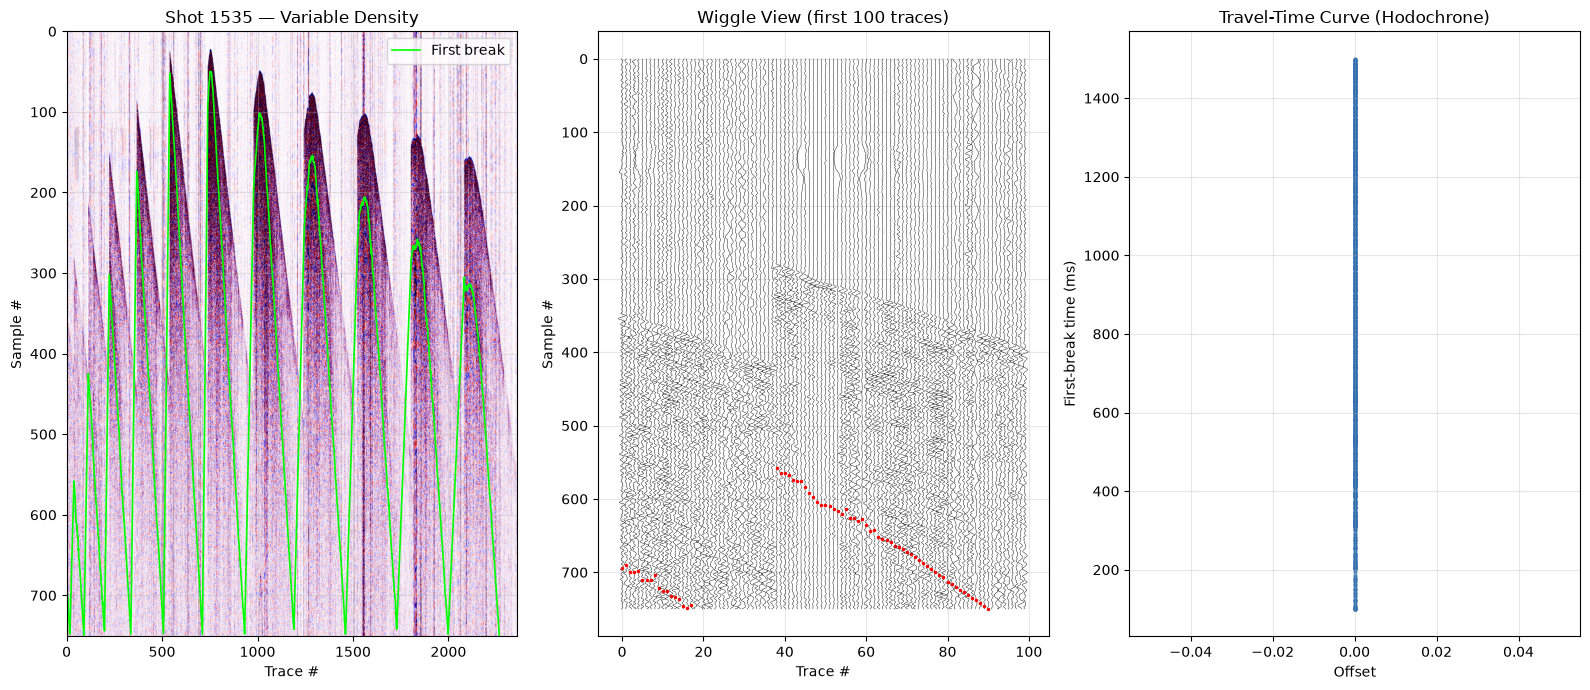

Shot 1535: 2361 traces, 1678 valid picks (71.1%), pick range 50-750 samples


In [16]:
def get_shot_gather(shot_id, file_path=FILE_PATH, group_path=GROUP_PATH,
                     shot_boundaries=shot_boundaries, shotids_arr=shotids):
    """Return (data, {field: picks}, offsets) for one shot gather, using a fast contiguous
    slice when possible and falling back to boolean indexing otherwise."""
    with h5py.File(file_path, "r") as f:
        group = f[group_path]
        if shot_boundaries is not None and int(shot_id) in shot_boundaries:
            start, end = shot_boundaries[int(shot_id)]
            data = group["data_array"][start:end, :]
            offs = (group["OFFSET_FLT"][start:end, 0] if "OFFSET_FLT" in group
                    else group["OFFSET"][start:end, 0])
            pick_data = {fld: group[fld][start:end, 0] for fld in PICK_FIELD_CANDIDATES if fld in group}
        else:
            mask = (shotids_arr == shot_id)
            data = group["data_array"][()][mask]
            offs = (group["OFFSET_FLT"][()][mask, 0] if "OFFSET_FLT" in group
                    else group["OFFSET"][()][mask, 0])
            pick_data = {fld: group[fld][()][mask, 0] for fld in PICK_FIELD_CANDIDATES if fld in group}
    return data, pick_data, offs


def plot_shot_gather(shot_id, pick_field=main_pick_field, n_traces_wiggle=100):
    data, pick_data, offs = get_shot_gather(shot_id)
    picks_here = pick_data.get(pick_field, np.zeros(data.shape[0]))
    n_tr, n_samp = data.shape
    clip = np.percentile(np.abs(data), 95)
    valid = (picks_here > 0) & (picks_here < n_samp)

    fig, axes = plt.subplots(1, 3, figsize=(16, 7))

    # Panel 1 — variable density with FB overlay
    ax = axes[0]
    ax.imshow(data.T, cmap="seismic", aspect="auto", vmin=-clip, vmax=clip, extent=[0, n_tr, n_samp, 0])
    ax.plot(np.arange(n_tr)[valid] + 0.5, picks_here[valid], color="lime", lw=1.2, label="First break")
    ax.set_xlabel("Trace #"); ax.set_ylabel("Sample #")
    ax.set_title(f"Shot {shot_id} — Variable Density")
    ax.legend(loc="upper right")

    # Panel 2 — wiggle view
    ax = axes[1]
    n_show = min(n_traces_wiggle, n_tr)
    for i in range(n_show):
        tr = data[i, :]
        tr = tr / (np.max(np.abs(tr)) + 1e-10)
        ax.plot(tr * 0.9 + i, np.arange(n_samp), "k-", lw=0.3)
        if valid[i]:
            ax.plot(i, picks_here[i], "r.", ms=3)
    ax.invert_yaxis()
    ax.set_xlabel("Trace #"); ax.set_ylabel("Sample #")
    ax.set_title(f"Wiggle View (first {n_show} traces)")

    # Panel 3 — hodochrone (offset vs. pick time)
    ax = axes[2]
    ax.scatter(offs[valid], picks_here[valid] * dt_ms, s=4, alpha=0.5, color="#2b6cb0")
    ax.set_xlabel("Offset"); ax.set_ylabel("First-break time (ms)")
    ax.set_title("Travel-Time Curve (Hodochrone)")

    plt.tight_layout()
    plt.show()

    if valid.sum():
        print(f"Shot {shot_id}: {n_tr} traces, {valid.sum()} valid picks ({100*valid.sum()/n_tr:.1f}%), "
              f"pick range {picks_here[valid].min():.0f}-{picks_here[valid].max():.0f} samples")
    else:
        print(f"Shot {shot_id}: {n_tr} traces, 0 valid picks")


sample_shots = rng.choice(unique_shots, size=min(4, n_shots), replace=False)
for sid in sample_shots:
    plot_shot_gather(sid)


### 4.1 Survey-wide travel-time density (outlier-pick QC)

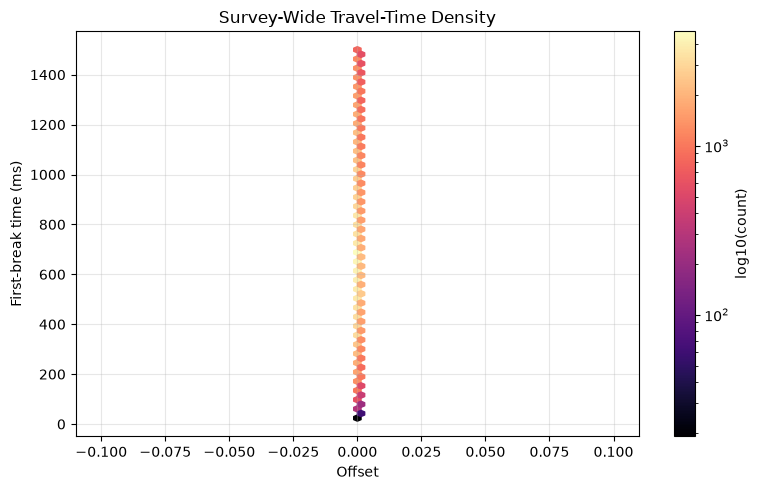

A tight, coherent trend (direct-arrival slope near the offset origin, refraction branches further out) indicates reliable picks survey-wide. Scattered points far from any coherent trend are candidate bad picks worth a manual QC pass before training.


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sample_idx3 = rng.choice(len(main_picks), size=min(200000, len(main_picks)), replace=False)
sel = sample_idx3[valid_mask[sample_idx3]]
hb = ax.hexbin(np.abs(offset[sel]), main_picks[sel] * dt_ms, gridsize=70, bins="log", cmap="magma")
ax.set_xlabel("Offset")
ax.set_ylabel("First-break time (ms)")
ax.set_title("Survey-Wide Travel-Time Density")
plt.colorbar(hb, label="log10(count)")
plt.tight_layout()
plt.show()
print("A tight, coherent trend (direct-arrival slope near the offset origin, refraction branches further out) "
      "indicates reliable picks survey-wide. Scattered points far from any coherent trend are candidate bad picks "
      "worth a manual QC pass before training.")


## 5. Senior-Level Insights & Preprocessing Recommendations

### 5.1 Resolve the label-field ambiguity *first*
This file exposes **three** candidate break-time fields (`SPARE1`, `FIRST_BREAK_TIME`, `MODELLED_BREAK_TIME`),
and the existing training pipeline hardcodes `SPARE1`. Section 2.2's cross-check either confirms `SPARE1` is a
safe proxy for `FIRST_BREAK_TIME`, or it isn't — in which case the segmentation masks (and therefore everything
downstream) are being built against the wrong ground truth. This is a five-minute check that should gate
everything else. `MODELLED_BREAK_TIME` is also worth keeping around post-training as an *independent* QC
signal (large pick-vs-model residuals flag traces where the network is likely to struggle or be wrong).

### 5.2 Filter dead / low-quality traces before training, not after
The current `load_all_shots_optimized()` function pads or crops every shot to `TARGET_TRACES=1578` but never
excludes dead traces (Section 3.2) or checks `TRTYPE`. Dead traces contribute pure noise to both the input
(flat/near-zero trace) and — worse — their pick defaults to 0, which the mask builder currently encodes as
"before-break" (class 0), i.e. **indistinguishable from a real early first break**. Recommendation: build an
explicit `is_valid_trace` mask (RMS above threshold AND `TRTYPE` says live AND pick is valid) and either drop
those traces from the gather or exclude their pixels from the loss (see 5.5).

### 5.3 Normalize per trace, not globally
Section 3.3 shows amplitude falls off sharply with offset — a single global scale factor will make far-offset
traces nearly invisible to the network relative to near-offset traces. Standard practice for this task:
- Per-trace max-abs or RMS normalization (divide each trace by its own peak or RMS amplitude, done in the
  visualization code above and worth adopting in the training pipeline too), or
- A robust/percentile-based scale (e.g. divide by the 95th-percentile |amplitude| of the trace) to reduce
  sensitivity to single-sample spikes.

### 5.4 Consider bandpass filtering
`LOW_CUT_FREQ`/`HIGH_CUT_FREQ` and the sweep parameters in the header set (Section 1) describe what the
*instrument* already applied at acquisition — they don't tell you what's actually useful signal band for
picking. A quick amplitude spectrum (FFT) on a handful of traces, then a bandpass (typically removing very
low frequencies dominated by ground-roll/surface waves, and very high frequencies dominated by ambient noise)
tends to sharpen the first-break onset and make the segmentation boundary less ambiguous. Tune the exact
corners empirically on this survey rather than reusing a value from another dataset.

### 5.5 Fix how padding interacts with the loss
Shots with fewer than `TARGET_TRACES` traces are zero-padded (Section 2.1 shows the traces-per-shot spread —
some shots will need this). Padded traces get pick=0 → mask class 0, again indistinguishable from a genuine
early first break. Two fixes, in order of preference:
1. Add a boolean `valid_trace` channel (or use `CrossEntropyLoss(..., ignore_index=IGNORE)` with padded/invalid
   pixels set to `IGNORE`) so padding never contributes gradient.
2. At minimum, exclude padded/dead/unlabeled traces when computing the empirical class weights (5.6) so they
   don't silently inflate the "before-break" class.

### 5.6 Recompute class weights empirically (don't guess them)
The current `class_weights = [0.004, 0.004, 0.992]` is a manual guess. Section 5.7 below computes the actual
pixel-level class balance for the 3-class strip mask from a sample of real shots — use that (or the full-dataset
version of the same computation) instead.

### 5.7 Guard against spatial leakage in the train/val/test split
The current split (`train_test_split` on shot index) is random at the shot level, which is good — but this is
a **3D survey** (`Halfmile3D`), where adjacent shots along a line are spatially correlated (similar near-surface
geology, similar statics, similar noise character). A purely random split can let the model "see" the
subsurface conditions of a test shot's neighbours during training via a nearby train shot, inflating validation
metrics. Consider a spatial split instead: hold out entire `LINE`/`INLINE` ranges or a contiguous `SHOTID` block
for validation/test, and compare metrics against the random split to see how much they diverge.

### 5.8 Data augmentation for noise robustness
The `first_breaks_picking` methodology this project follows explicitly targets robustness to noisy data.
Once the clean-data pipeline above works, consider augmenting training gathers with: synthetic noise injection
scaled to the per-trace RMS distribution found in Section 3.2, random trace dropout/muting (simulating dead
channels), and small time-shift jitter — all of which are cheap ways to close the gap between "good quality"
and "noisy" field performance mentioned in the reference methodology.


### 5.9 Empirical class-weight recomputation (sample-based)

In [18]:
# Recompute the 3-class pixel balance (before / strip / after) from a random sample of real
# shots, using the label field chosen in Section 2.2 — replaces the guessed static weights.
STRIP_WIDTH = 8
sample_shot_ids = rng.choice(unique_shots, size=min(30, n_shots), replace=False)
class_counts = np.zeros(3, dtype=np.int64)

for sid in tqdm(sample_shot_ids, desc="Sampling shots for class balance"):
    data, pick_data, _ = get_shot_gather(sid)
    p = pick_data.get(main_pick_field, np.zeros(data.shape[0]))
    n_tr, n_samp = data.shape
    hw = STRIP_WIDTH // 2
    for pick in p:
        if pick <= 0 or pick >= n_samp:
            class_counts[0] += n_samp  # whole trace falls into the "before/unlabeled" bucket
            continue
        pick_i = int(round(pick))
        s, e = max(0, pick_i - hw), min(n_samp, pick_i + hw + 1)
        class_counts[2] += (e - s)
        class_counts[1] += (n_samp - e)
        class_counts[0] += s

total = class_counts.sum()
class_freq = class_counts / total
empirical_weights = 1.0 / class_freq
empirical_weights = empirical_weights / empirical_weights.sum()

print("Empirical class pixel counts (before, after, strip):", class_counts)
print("Empirical class frequencies:", np.round(class_freq, 4))
print("Suggested empirical class weights (normalized inverse-frequency):", np.round(empirical_weights, 4))
print("\nOriginal pipeline used fixed weights [0.004, 0.004, 0.992] for classes "
      "[before, after, strip] respectively — compare index-by-index against the empirical "
      "values above (note the class ORDER above is [before, after, strip], matching class_counts) "
      "and update if they diverge meaningfully.")


Empirical class pixel counts (before, after, strip): [39066859 23866109   576098]
Empirical class frequencies: [0.6151 0.3758 0.0091]
Suggested empirical class weights (normalized inverse-frequency): [0.0142 0.0232 0.9626]

Original pipeline used fixed weights [0.004, 0.004, 0.992] for classes [before, after, strip] respectively — compare index-by-index against the empirical values above (note the class ORDER above is [before, after, strip], matching class_counts) and update if they diverge meaningfully.


## 6. Summary & Recommended Order of Operations

1. **Reconcile** `SPARE1` vs `FIRST_BREAK_TIME` (§2.2) — pick the correct label field before anything else.
2. **Filter** dead/invalid traces using RMS + `TRTYPE` (§3.2) before building gathers.
3. **Normalize** each trace independently (§5.3) to counter geometric-spreading amplitude decay (§3.3).
4. Optionally **bandpass filter** based on an FFT check of the actual noise/signal band (§5.4).
5. **Rebuild segmentation masks** so padded/invalid/dead pixels are excluded from the loss, not folded into
   class 0 (§5.5).
6. **Recompute class weights** empirically (§5.9) rather than reusing a manual guess.
7. Re-split train/val/test **spatially**, or at least benchmark the random split against a spatial one (§5.7),
   given this is a 3D survey.
8. Only then resume U-Net training with the existing model architecture — the architecture itself doesn't need
   to change for any of the above; the data pipeline does.
